# Tutorial \#4: Coverage Prediction using Geo2SigMap's ML Model and Comparison with Measurement Data

This tutorial demonstrates the complete workflow for:
1. **Scene Generation**: Creating 2D building maps for specified PCI locations;
2. **Data Preparation**: Processing real-world measurement data;
3. **Model Inference**:
  - 1st U-Net: Isotropic antenna pattern prediction;
  - 2nd U-Net: Fine-grained prediction with sparse measurements;
4. **Performance Evaluation**: Quantitative comparison with ground truth (field measurements).

**Technical Specifications**:
- Area size: 512m x 512m;
- Spatial resolution: 4m x 4m (per pixel);
- Model input/output dimension: 128 × 128 (pixel x pixel)

**Prerequisites**:
- Please make sure that **PyTorch** is installed: check the [PyTorch website](https://pytorch.org/get-started/locally/) for more info.;
- Download the pre-trained model weights for Geo2SigMap's deep learning (DL) model and save them to `data/model_unet/`.

In [1]:
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import math
import random

from scene_generation.core import Scene
from scene_generation.utils import *
from scene_generation.empirical_pathloss_model import pathloss_38901
from scene_generation.unet.unet_model_rt import UNet

from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver
from scipy.io import loadmat

import os


/Users/rtang/miniconda3/envs/g2smrefreshed/lib/python3.12/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Experimental Setup

**Configuration**:
- Target PCI: A
- Measurement device: Samsung
- Number of sparse measurement samples input to the DL model: 200

For detailed information about the measurement device and PCI, refer to our [paper](https://arxiv.org/pdf/2312.14303).

In [2]:
mea_device = "Samsung"
which_PCI = "A"
SS_NUM = 200
RESOLUTION = 4

rt_dict = {
    "rel_top_left_x":[],
    "rel_top_left_y":[],
    "rel_center_x":[],
    "rel_center_y":[],
}


scene_dir = "../scenes/Duke_{}".format(which_PCI)

state_dict_1st_UNet = "../data/model_unet/1st_checkpoint_epoch58.pth"
state_dict_2nd_UNet = "../data/model_unet/2nd_checkpoint_epoch110.pth"

cell_info_dict = {
    'PCI':['A', 'B', 'C', 'D','E', 'F' ],
    'center_lat_lon':[
        (35.999186254897836, -78.9397858960648),
        (35.999186254897836, -78.9397858960648),
        (35.999186254897836, -78.9397858960648),
        (35.999186254897836, -78.9397858960648),
        (36.00307128210248, -78.93706070613855),
        (36.00307128210248, -78.93706070613855)
    ],
    'top-left_lat_lon':[
        (36.001483241320656, -78.94273733701348),
        (36.001483241320656, -78.94273733701348),
        (36.001483241320656, -78.94273733701348),
        (36.001483241320656, -78.94273733701348),
        (36.005429554748495, -78.93998431793196), 
        (36.005429554748495, -78.93998431793196), 
    ],
    'azimuth':[212, 212, 30, 30, 216, 216 ],
    'freq':[3.69e9, 3.64e9, 3.58e9, 3.56e9, 3.69e9, 3.64e9 ]
}

cell_info_df = pd.DataFrame(cell_info_dict)

## 1. Scene Generation

Different from the CLI tools `scenegen`, here we will directly use the Python function API to generate the scene. The Python function provides more flexibility than the CLI tool for advanced use cases.


In [3]:
polygon_points_gps = rect_from_point_and_size(
    cell_info_df[cell_info_df["PCI"] == which_PCI]['top-left_lat_lon'][0][1],
    cell_info_df[cell_info_df["PCI"] == which_PCI]['top-left_lat_lon'][0][0],
    "top-left", 
    512,
    512
)
min_lon, min_lat = polygon_points_gps[0]
max_lon, max_lat = polygon_points_gps[2]
print(
    f"Check the bbox at http://bboxfinder.com/#{min_lat:.{4}f},{min_lon:.{4}f},{max_lat:.{4}f},{max_lon:.{4}f}"
)

scene_instance = Scene()
scene_instance(
    polygon_points_gps,
    scene_dir,
    None,
    osm_server_addr="https://overpass-api.de/api/interpreter",
    #osm_server_addr="http://192.168.1.101/api/interpreter",
    lidar_calibration=False,
    generate_building_map=True,
    building_height_priority="osm-first"
)

utm_epsg = get_utm_epsg_code_from_gps(
    cell_info_df[cell_info_df["PCI"] == which_PCI]['top-left_lat_lon'][0][1],
    cell_info_df[cell_info_df["PCI"] == which_PCI]['top-left_lat_lon'][0][0],
)

Check the bbox at http://bboxfinder.com/#35.9969,-78.9429,36.0014,-78.9371


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Parsing buildings: 100%|██████████| 58/58 [00:00<00:00, 388.51it/s]


### Preview the Generated Scene

Load the scene into Sionna RT and visually inspect the 3D building geometry —
a quick sanity check before running inference.

You can use the following controls:
* Mouse left: Rotate
* Scroll wheel: Zoom
* Mouse right: Move

In [4]:

# Load scene and access Mitsuba's internal representation
scene = load_scene(os.path.join(scene_dir,"scene.xml"))

# Interative 3D visualization and view of the scene
scene.preview();

2026-06-09 15:41:41 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


### Inspect and Downsample the 2D Building Height Map

The scene generator writes a `2D_Building_Height_Map.npy` alongside `scene.xml`.
Each pixel represents 1 m² and its value is the building height in metres (0 = open ground).

Because the ML model operates on a **128 × 128** grid at **4 m/pixel resolution**,
we apply two preprocessing steps:

1. **Crop** to a centre 512 × 512 m sub-array
2. **Downsample** by a factor of 4 (every 4th pixel) to produce the 128 × 128 model input

Original Building Map Shape: (512, 512)
Cropped Building Map Shape:  (512, 512)


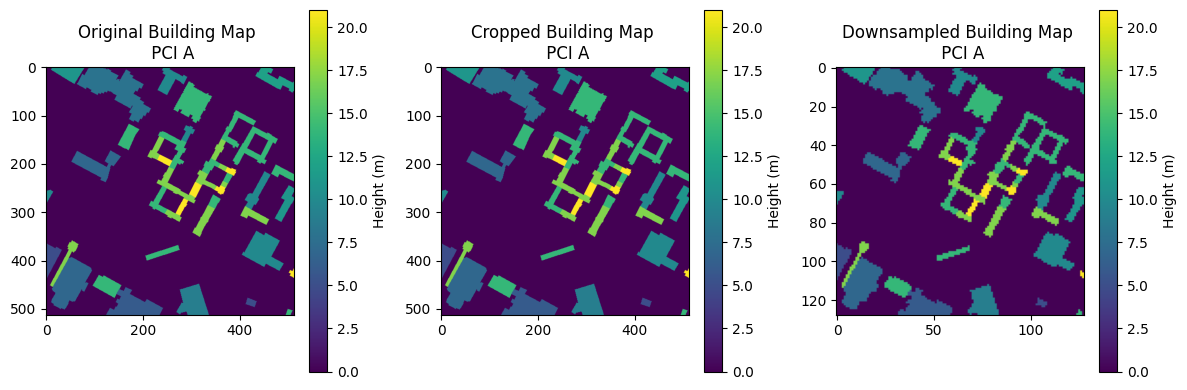

In [5]:
building_map_npy_ori = np.load("{}/2D_Building_Height_Map.npy".format(scene_dir))

print("Original Building Map Shape:", building_map_npy_ori.shape)
building_map_npy = get_center_subarray(building_map_npy_ori, 512, 512)
print("Cropped Building Map Shape: ", building_map_npy.shape)

building_map_npy_res_4 = building_map_npy[::4,::4]

# Create side-by-side plots for original, cropped, down-sampled building map
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# 1) Original building map
im_ori_bmap = axes[0].imshow(building_map_npy_ori)
axes[0].set_title('Original Building Map \n PCI {}'.format(which_PCI))
cbar_raw = plt.colorbar(im_ori_bmap, ax=axes[0])
cbar_raw.set_label('Height (m)')

# 2) Cropped building map (center 512x512 subarray)
im_cropped_bmap = axes[1].imshow(building_map_npy)
axes[1].set_title('Cropped Building Map \n PCI {}'.format(which_PCI))
cbar_db = plt.colorbar(im_cropped_bmap, ax=axes[1])
cbar_db.set_label('Height (m)')

# 3) Down sampled building map
im_ds_bmap = axes[2].imshow(building_map_npy_res_4)
axes[2].set_title('Downsampled Building Map \n PCI {}'.format(which_PCI))
cbar_db_flip = plt.colorbar(im_ds_bmap, ax=axes[2])
cbar_db_flip.set_label('Height (m)')

plt.tight_layout()
plt.show()

## 2. Measurement Data Preparation


**Note:** Check tutorial `3_visualize_measurements.ipynb` for better visualization of measurement data.

In [6]:
measurement_data = pd.read_csv("../data/measurements/Duke_CBRS.csv")

# Filter out the measurement data collected by a specified device and/or PCI
measurement_data_filtered = measurement_data[(measurement_data['PCI'] == which_PCI) & (measurement_data['device'] == mea_device)]

measurement_data_filtered

,PCI,latitude,longitude,device,rsrp
203,A,35.998821,-78.940651,Samsung,-80
571,A,35.999005,-78.940536,Samsung,-88
573,A,35.998797,-78.940672,Samsung,-81
598,A,35.999466,-78.940202,Samsung,-110
600,A,35.998288,-78.939732,Samsung,-88
...,...,...,...,...,...
20348,A,35.999540,-78.940308,Samsung,-103
20349,A,35.998634,-78.943191,Samsung,-115
20351,A,35.995545,-78.943101,Samsung,-103
20352,A,35.995504,-78.939662,Samsung,-110


### Rasterize Measurements onto the Model Grid

Raw GPS measurements are converted to the same 128 × 128 local coordinate grid
used by the ML model using the following steps:

1. **GPS → UTM** — project lat/lon into the UTM zone that covers the scene
2. **UTM → pixel** — subtract the scene's top-left UTM corner and divide by the 4 m cell resolution
3. **Aggregate per pixel** — multiple measurements in the same cell are merged using the
   linear-domain mean (power averaging)

Pixels that overlap building footprints are filtered out, as indoor GPS fixes are
almost certainly multipath artefacts.

Total number of measurements:  1850
Total # of pixels after rasterization to 4m resolution: 550
Total # of valid pixels (no overlapping with buildings):  530


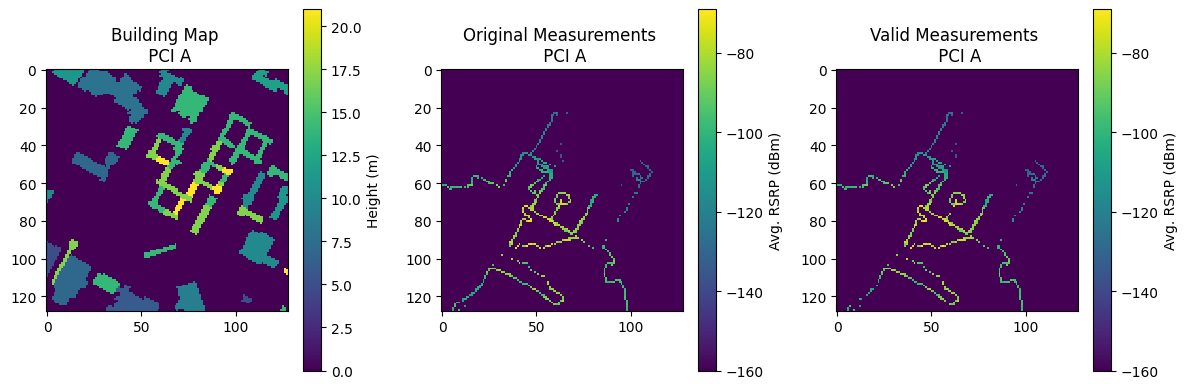

In [7]:
# Generate a list of tuples (numpy_row, numpy_col, rsrp) by converting the (lat, lon) into local coordinates
measurement = np.empty([len(measurement_data_filtered["latitude"]), 3])
measurement[:, 0] = measurement_data_filtered["latitude"]
measurement[:, 1] = measurement_data_filtered["longitude"]
measurement[:, 2] = measurement_data_filtered["rsrp"]

top_left_coord_x_utm,top_left_coord_y_utm, _   = gps_to_utm_xy(
    cell_info_df[cell_info_df["PCI"] == which_PCI]['top-left_lat_lon'][0][1],
    cell_info_df[cell_info_df["PCI"] == which_PCI]['top-left_lat_lon'][0][0],
    utm_epsg)

for idx, point in enumerate(measurement):
    mea_x_utm, mea_y_utm, _ = gps_to_utm_xy(measurement[idx,1], measurement[idx,0], utm_epsg)
    row = top_left_coord_y_utm - mea_y_utm 
    col =  mea_x_utm - top_left_coord_x_utm
    
    measurement[idx, 0] = row
    measurement[idx, 1] = col

ground_truth_list = measurement

print("Total number of measurements: ", len(ground_truth_list))

ground_truth_tmp = np.empty((128, 128), dtype=object)
count_num_no_building = 0

for point in ground_truth_list:
    row = int(point[0]/4)
    col = int(point[1]/4)
    if row >=128 or col >= 128 or row < 0 or col < 0:
        # print("{}:{}".format(row,col))
        continue
    if ground_truth_tmp[row, col] is None:
        ground_truth_tmp[row, col] = np.array(point[2])
    else:
        ground_truth_tmp[row][col] = np.append(ground_truth_tmp[row][col], point[2])

ground_truth_arr = np.empty((128, 128))
for row in range(128):
    for col in range(128):
        if ground_truth_tmp[row, col] is None:
            ground_truth_arr[row][col] = -160
        else:
            # ground_truth_arr[row][col] = ground_truth_tmp[row,col].mean()
            # ground_truth_arr[row][col] = np.median(ground_truth_tmp[row,col])
            ground_truth_arr[row][col] = 10 * np.log10( ( 10 ** ( ground_truth_tmp[row,col]/ 10)  ).mean() )

# Filter out the pixels blocked by the building (e.g., due to GPS and/or geographical data error)
condition = (ground_truth_arr != -160) & (building_map_npy_res_4 != 0)

ground_truth_arr_valid = ground_truth_arr.copy()
ground_truth_arr_valid[condition] = -160  # Update values

print("Total # of pixels after rasterization to 4m resolution: {}".format(np.sum(ground_truth_arr != -160))) 
print("Total # of valid pixels (no overlapping with buildings):  {}".format(np.sum(ground_truth_arr_valid != -160)))
  
# Create side-by-side plots for original, cropped, down-sampled building map
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# 1) Building map
im_bmap = axes[0].imshow(building_map_npy_res_4, interpolation='none')
axes[0].set_title('Building Map \n PCI {}'.format(which_PCI))
cbar_raw = plt.colorbar(im_bmap, ax=axes[0])
cbar_raw.set_label('Height (m)')

# 2) TX positional map
im_ori_mea = axes[1].imshow(ground_truth_arr, interpolation='none')
axes[1].set_title('Original Measurements \n PCI {}'.format(which_PCI))
cbar_db = plt.colorbar(im_ori_mea, ax=axes[1])
cbar_db.set_label('Avg. RSRP (dBm)')

# 3) Pathloss
im_valid_mea = axes[2].imshow(ground_truth_arr_valid, interpolation='none')
axes[2].set_title('Valid Measurements \n PCI {}'.format(which_PCI))
cbar_db_flip = plt.colorbar(im_valid_mea, ax=axes[2])
cbar_db_flip.set_label('Avg. RSRP (dBm)')

plt.tight_layout()
plt.show()

### Sample Sparse Measurements for the 2nd U-Net

The 2nd U-Net takes **sparse** field measurements as a guidance channel.
We randomly select `SS_NUM` pixels from the valid outdoor measurement set to simulate
a realistic partial-coverage deployment scenario, where measurements are only available
at a small fraction of locations.

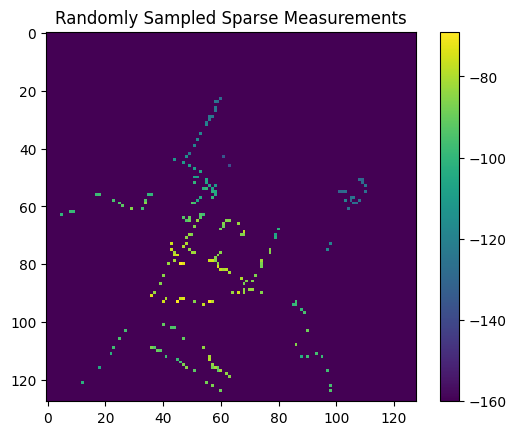

In [8]:
ss_map = np.full((128, 128), -160)

# Get valid positions (where ground_truth_arr_valid != -160)
valid_positions = np.argwhere(ground_truth_arr_valid != -160)  # Get (row, col) indices
    
# Randomly select SS_NUM positions from valid ones
# Note that the selected measurements vary from run to run if no seed is specified
selected_indices = valid_positions[np.random.choice(len(valid_positions), SS_NUM, replace=False)]

# Copy values from the original array to the ss_map at selected positions
for row, col in selected_indices:
    ss_map[row, col] = ground_truth_arr_valid[row, col]
    # Save the positions to rt_dict for raytracing
    rt_dict["rel_top_left_y"].append(row)
    rt_dict["rel_top_left_x"].append(col)
    center_x, center_y = top_left_to_center(row, col, 128, 128)
    rt_dict["rel_center_x"].append(center_x)
    rt_dict["rel_center_y"].append(center_y)
    


    
plt.imshow(ss_map, interpolation='none')
plt.title("Randomly Sampled Sparse Measurements")
plt.colorbar()
plt.show()

In [9]:
# Prepare the RT results:
rt_df = pd.DataFrame(rt_dict)
rt_df

,rel_top_left_x,rel_top_left_y,rel_center_x,rel_center_y
0,44,102,38.0,20.0
1,49,46,-18.0,15.0
2,103,55,-9.0,-39.0
3,40,101,37.0,24.0
4,35,56,-8.0,29.0
...,...,...,...,...
195,56,93,29.0,8.0
196,51,59,-5.0,13.0
197,50,59,-5.0,14.0
198,56,79,15.0,8.0


### Configure Transmitters and Receivers

We configure antenna arrays and place Sionna `Transmitter` and `Receiver` objects:

- The **TX** uses the 3GPP TR 38.901 (`tr38901`) directional pattern with the azimuth
  angle from `cell_info_dict`, mounted at 25 m height
- Each **RX** is placed at 1.5 m height (typical UE height) at the centre of each
  sampled measurement pixel
- `scene.frequency` is set to the PCI-specific CBRS carrier

In [10]:
# Array configurations

# Transmitter array (single isotropic element)
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",        # isotropic pattern
    polarization="V"      # vertical polarization
)

# Receive array (single dipole element)
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V"
)

# Transmitter configuration
tx0 = Transmitter(
    name="tx",
    position=[0, 0, 25],  # Elevated position
    orientation=[-1 * float(cell_info_df[cell_info_df["PCI"] == which_PCI]['azimuth'][0] - 90) / 180 * np.pi, 0, 0]  # 210° azimuth tilt
)

scene.add(tx0)

# Random select 10 receivers form valid_positions (Outdoor positions)
# for i, pos in enumerate(valid_positions[np.random.choice(valid_positions.shape[0], size=10, replace=False)]):
for index, row in rt_df.iterrows():
    rx = Receiver(
        name=f"rx_{index}",
        position=(float(np.mean((-1 *(row["rel_center_y"]+1)*4, -1 *row["rel_center_y"]*4))), float(np.mean((-1 * (row["rel_center_x"]+1)*4, -1 * row["rel_center_x"]*4))), 1.5),
        orientation=[0, 0, 0] 
    )
    scene.add(rx)

### Preview the Scene with TX and RX Positions

Confirm that the transmitter and all receiver positions appear correctly in the
3D scene before running ray tracing.

In [11]:
# Preview scene
scene.preview();

### Run Point-to-Point Ray Tracing

`PathSolver` shoots rays from the TX and records all paths that reach each RX.
Key parameters:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `max_depth` | 3 | Maximum number of reflections per path |
| `los` | True | Include line-of-sight paths |
| `specular_reflection` | True | Include specular reflection |
| `samples_per_src` | 1 × 10⁶ | Number of rays shot from the source |

In [12]:
# Configure simulation parameters
scene.frequency = cell_info_df[cell_info_df["PCI"] == which_PCI]['freq'][0]
print(f"Frequency: {scene.frequency/1e9} GHz")

scene.synthetic_array = True  # Optimize for array calculations

# Perform ray tracing
solver = PathSolver()
paths = solver(scene, max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=False,
    samples_per_src=int(1e6)
)

Frequency: [3.69] GHz


### Parse Ray Tracing Results into a DataFrame

`create_ray_dataset` extracts per-path attributes from the Sionna `paths` object
and organises them into a tidy DataFrame for analysis.

| Column | Description |
|--------|-------------|
| `a` | Complex path gain |
| `tau` | Path delay (s) |
| `type` | Interaction type — LOS, SPECULAR, DIFFUSE, or REFRACTION |
| `rx_id` | Receiver index |
| `phi_r` / `phi_t` | Azimuth angles at RX and TX (rad) |
| `theta_r` / `theta_t` | Elevation angles at RX and TX (rad) |

In [13]:
# Create a structured dataset
def create_ray_dataset(ray_dict, frequency):
    """Process raw ray data into pandas DataFrame"""
    dataset = {
        'freq': [],
        'rx_id': [],
        'type': [],
        'phi_r': [],
        'phi_t': [],
        'theta_r': [],
        'theta_t': [],
        'a':[],
        'tau':[],
        'rx_coord':[]
    }
    
     # See sionna.rt.constants.InteractionType
    ray_type_map = {0: "LOS", 1: "SPECULAR", 2: "DIFFUSE", 4: "REFRACTION"}
    
    a = np.asarray(paths.a).squeeze()
    tau = np.asarray(paths.tau).squeeze()
    types = np.asarray(paths.interactions).squeeze()
    mask = np.asarray(paths.valid).squeeze()
    phi_r = np.asarray(paths.phi_r).squeeze()
    phi_t = np.asarray(paths.phi_t).squeeze()
    theta_r = np.asarray(paths.theta_r).squeeze()
    theta_t = np.asarray(paths.theta_t).squeeze()
    
    # Extract relevant parameters
    for idx, item in enumerate(mask):
        # Filter out the RX if it has no valid paths
        if np.sum(item==True):
            for sub_idx, sub_item in enumerate(item):
                if sub_item:
                    cur_ray_type = 0
                    for depth_idx in range(3-1, -1, -1):
                        cur_ray_type = types[depth_idx,idx,sub_idx]
                        # print(f"types[{depth_idx},{idx},{sub_idx}]",cur_ray_type)
                        if cur_ray_type != 0:
                            break

                    # Store the list instead of np.array to avoid the space separator in .csv
                    dataset["freq"].append(frequency)
                    dataset["type"].append(ray_type_map[cur_ray_type])
                    z = np.complex64(a[0,idx,sub_idx] + 1j*a[1, idx,sub_idx]) 
                    dataset["a"].append(z)
                    dataset["tau"].append(tau[idx,sub_idx])
                    dataset["rx_id"].append(idx)
                    dataset["rx_coord"].append(valid_positions[idx].tolist())
                    dataset["phi_r"].append(phi_r[idx,sub_idx ])                    
                    dataset["phi_t"].append(phi_t[idx,sub_idx])
                    dataset["theta_r"].append(theta_r[idx,sub_idx])
                    dataset["theta_t"].append(theta_t[idx,sub_idx])

    return pd.DataFrame(dataset)

# Generate analysis dataframe
df = create_ray_dataset(paths, frequency=28e9)
df.head()

,freq,rx_id,type,phi_r,phi_t,theta_r,theta_t,a,tau,rx_coord
0,2.800000e+10,0,LOS,1.081513,-2.060080,1.436909,1.704684,0.000109+0.000000j,5.872267e-07,"[23, 59]"
1,2.800000e+10,0,SPECULAR,1.081513,-2.060080,1.721531,1.721532,-0.000022-0.000005j,5.886462e-07,"[23, 59]"
2,2.800000e+10,0,SPECULAR,-2.082400,-2.064597,1.671204,1.671209,0.000012-0.000000j,8.817590e-07,"[23, 59]"
3,2.800000e+10,0,SPECULAR,-2.082400,-2.064597,1.481683,1.659909,-0.000031+0.000004j,8.808120e-07,"[23, 59]"
4,2.800000e+10,0,SPECULAR,1.102074,-2.078627,1.621831,1.621833,-0.000004+0.000001j,1.732673e-06,"[23, 59]"


### Compute Per-RX Signal Strength from Ray Paths

The received power is proportional to the total squared path gain across all paths.
For each RX we accumulate contributions and convert to dB:

$$P_{\text{rx}} = 10 \log_{10} \sum_i |a_i|^2$$

The resulting dB values are merged with the pixel coordinates so they can be
mapped back onto the measurement grid for comparison.

In [14]:
# Compute the absolute values of 'a' and sum by 'rx_id'
signal_strength = df.groupby('rx_id')['a'].apply(lambda x: 10 * np.log10(np.power(np.abs(x),2).sum())).reset_index()

# Rename the column for clarity
signal_strength.columns = ['rx_id', 'Path Gain']
print(len(signal_strength))

# Merge the signal strength DataFrame with the measurement DataFrame
signal_strength_db = signal_strength.merge(rt_df, left_on='rx_id', right_index=True, how='left')

signal_strength_db

130


,rx_id,Path Gain,rel_top_left_x,rel_top_left_y,rel_center_x,rel_center_y
0,0,-78.663216,44,102,38.0,20.0
1,1,-97.805008,49,46,-18.0,15.0
2,3,-78.794708,40,101,37.0,24.0
3,4,-90.466194,35,56,-8.0,29.0
4,5,-79.645859,66,66,2.0,-2.0
...,...,...,...,...,...,...
125,195,-77.159897,56,93,29.0,8.0
126,196,-86.954353,51,59,-5.0,13.0
127,197,-86.773254,50,59,-5.0,14.0
128,198,-87.491768,56,79,15.0,8.0


### Visualize Real vs. Sionna-generated Sparse Measurements

Side-by-side comparison of the two sparse measurement maps:

- **Left** — randomly sampled field RSRP measurements (`ss_map`)
- **Right** — Sionna RT path-gain estimates at those same receiver locations (`rt_ss_map`)

This comparison indicates how well ray-traced signal strength aligns with
real-world RSRP before either map is fed into the 2nd U-Net.

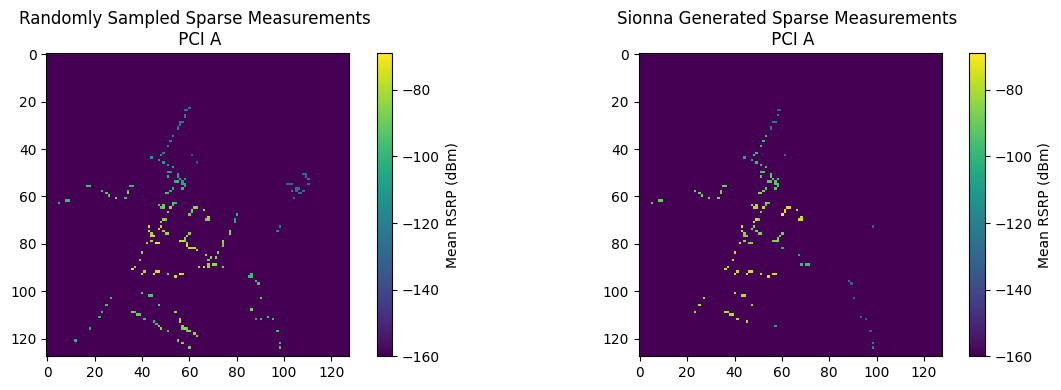

In [15]:
rt_ss_map = np.full((128, 128), -160)

for index, row in signal_strength_db.iterrows():
    rt_ss_map[int(row["rel_top_left_y"])][int(row["rel_top_left_x"])] = row["Path Gain"]

# Create side-by-side plots for the original, cropped, and down-sampled maps
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# 1) Building map
im_bmap = axes[0].imshow(ss_map, interpolation='none')
axes[0].set_title('Randomly Sampled Sparse Measurements \n PCI {}'.format(which_PCI))
cbar_raw = plt.colorbar(im_bmap, ax=axes[0])
cbar_raw.set_label('Mean RSRP (dBm)')

# 2) TX positional map
im_ori_mea = axes[1].imshow(rt_ss_map, interpolation='none')
axes[1].set_title('Sionna Generated Sparse Measurements \n PCI {}'.format(which_PCI))
cbar_db = plt.colorbar(im_ori_mea, ax=axes[1])
cbar_db.set_label('Mean RSRP (dBm)')

plt.tight_layout()
plt.show()

## 3. **Model Inference**
### 3a — 1st U-Net: Isotropic Coverage Prediction

The first U-Net predicts a full 128 × 128 isotropic coverage map from three input channels:

| Channel | Content |
|---------|--------|
| 0 | 2D building height map (128 × 128) |
| 1 | TX position map — single pixel set to TX height, all others 0 |
| 2 | 3GPP UMa empirical path-loss map (distance-based baseline) |

The model output is a single-channel path-gain map (dB) that captures large-scale
signal propagation without directional or site-specific calibration.
This output is also used as the third input channel for the 2nd U-Net.

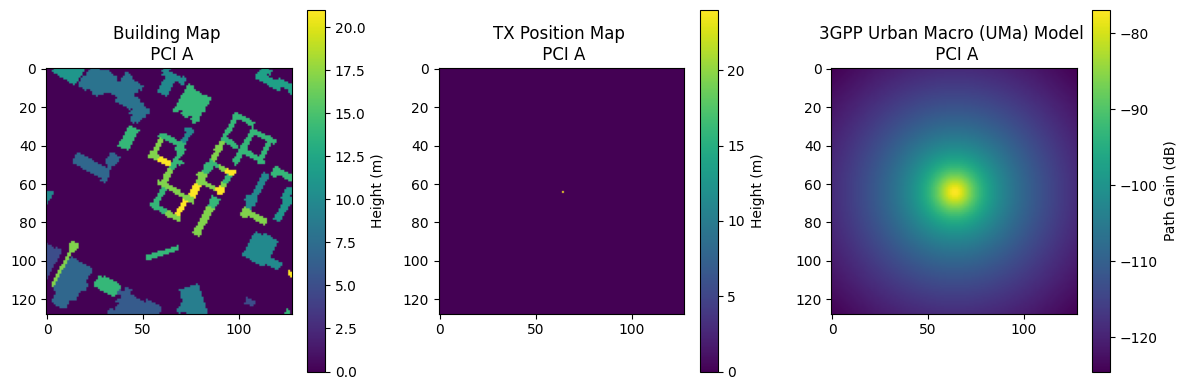

In [16]:
# Construct the TX position channel
tx_x = 256
tx_y = 256
tx_position = [tx_x // 4, tx_y // 4]
tx_height = 24
tx_position_channel = np.full((128, 128), 0, dtype=int)
# tx_height = np.max(building_height_arr)
tx_position_channel[tx_position[1]][tx_position[0]] = tx_height

distance = np.arange(0, 1450, 1)

# lookup table for path_loss_res, resolution=1 meter
path_loss_res, _ =  pathloss_38901(distance,3.64, h_bs=int(tx_height), h_ut=2)

path_loss_heat_map = np.full((128, 128), 0, dtype=float)

for row in range(path_loss_heat_map.shape[0]):
    for col in range(path_loss_heat_map.shape[1]):
        # Compute the distance between pixel and tx
        dist = math.sqrt((tx_position[1]*4 - row*4)**2 + (tx_position[0]*4 - col*4)**2) 
        path_loss_heat_map[row][col] =  -1 * path_loss_res[int(dist)]

net_iso = UNet(n_channels=2, n_classes=1, bilinear=False, pathloss=True)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
net_iso.to(device=device)

# Load the state dict
state_dict = torch.load(state_dict_1st_UNet, map_location=device)
net_iso.load_state_dict(state_dict)

# Combine all the channels together
combined_input = np.zeros((3, 128, 128), dtype=float)
combined_input[0,:, :] = np.copy(building_map_npy_res_4)
combined_input[1,:, :] = tx_position_channel
combined_input[2,:, :] = path_loss_heat_map

# Create side-by-side plots for building map, TX position map, and 3GPP UMa model map
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

im_bmap = axes[0].imshow(combined_input[0,:, :])
axes[0].set_title("Building Map \n PCI {}".format(which_PCI))
cbar_raw = plt.colorbar(im_bmap, ax=axes[0])
cbar_raw.set_label("Height (m)")

im_tx_pos = axes[1].imshow(combined_input[1,:, :])
axes[1].set_title("TX Position Map \n PCI {}".format(which_PCI))
cbar_db = plt.colorbar(im_tx_pos, ax=axes[1])
cbar_db.set_label("Height (m)")

im_uma = axes[2].imshow(combined_input[2,:, :])
axes[2].set_title("3GPP Urban Macro (UMa) Model \n PCI {}".format(which_PCI))
cbar_db_flip = plt.colorbar(im_uma, ax=axes[2])
cbar_db_flip.set_label("Path Gain (dB)")

plt.tight_layout()
plt.show()

### Run Inference with the 1st U-Net

Feed the combined three-channel input through the trained network in evaluation mode
(no gradient tracking). The output is the isotropic coverage prediction used as the
third input channel for the 2nd U-Net.

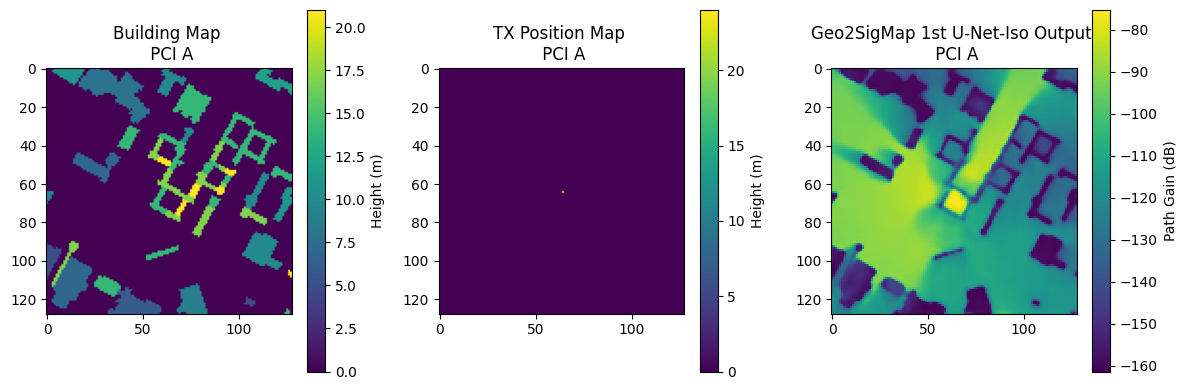

In [17]:
# Evaluation
images = torch.as_tensor(combined_input.copy()).float().contiguous()

# Since we load the data manually, add batch dimension to the front of the data
images = images[None,:, :, :]

net_iso.eval()

images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

with torch.no_grad():
    output = net_iso(images).squeeze().cpu()

output_iso_UNet = output.squeeze().cpu().numpy()


# Create side-by-side plots for the building map, TX position map, and 1st U-Net output map
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

im_bmap = axes[0].imshow(combined_input[0,:, :])
axes[0].set_title("Building Map \n PCI {}".format(which_PCI))
cbar_raw = plt.colorbar(im_bmap, ax=axes[0])
cbar_raw.set_label("Height (m)")

im_tx_pos = axes[1].imshow(combined_input[1,:, :])
axes[1].set_title("TX Position Map \n PCI {}".format(which_PCI))
cbar_db = plt.colorbar(im_tx_pos, ax=axes[1])
cbar_db.set_label("Height (m)")

im_1st_unet_output = axes[2].imshow(output_iso_UNet, interpolation="none")
axes[2].set_title("Geo2SigMap 1st U-Net-Iso Output \n PCI {}".format(which_PCI))
cbar_db = plt.colorbar(im_1st_unet_output, ax=axes[2])
cbar_db.set_label("Path Gain (dB)")

plt.tight_layout()
plt.show()

### 3b — 2nd U-Net: Directional, Measurement-Guided Prediction

The second U-Net refines the isotropic prediction using sparse measurements as
a guidance channel. It takes three inputs:

| Channel | Content |
|---------|--------|
| 0 | 2D building height map (128 × 128) |
| 1 | Sparse measurement map (`ss_map` or `rt_ss_map`) |
| 2 | 1st U-Net isotropic output |

Two variants are evaluated in parallel:
- **Measurement-guided** — uses real-world RSRP samples (`ss_map`)
- **RT-guided** — uses Sionna RT path-gain estimates as a surrogate (`rt_ss_map`)

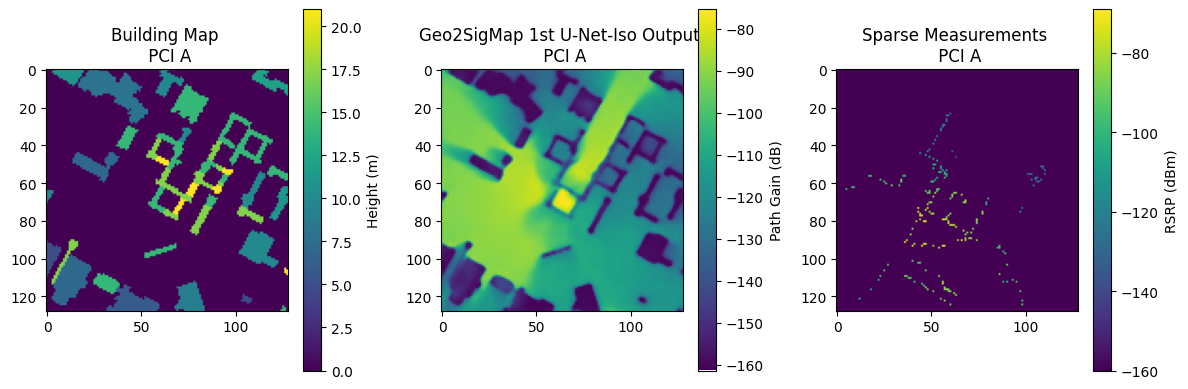

In [18]:
# 1. Create the model
net = UNet(n_channels=3, n_classes=1, bilinear=False, pathloss=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device=device)

# 2. Load the state dict
state_dict = torch.load(state_dict_2nd_UNet, map_location=device)
net.load_state_dict(state_dict)

combined_input = np.zeros((3, 128, 128), dtype=float)

rt_combined_input = np.zeros((3, 128, 128), dtype=float)

# Combine all the channels together
combined_input[0,:, :] = building_map_npy_res_4
combined_input[1,:, :] = ss_map
combined_input[2,:, :] = output_iso_UNet

rt_combined_input[0,:, :] = building_map_npy_res_4
rt_combined_input[1,:, :] = rt_ss_map
rt_combined_input[2,:, :] = output_iso_UNet

# Create side-by-side plots for the building map, 1st U-Net output map, and sparse measurement map
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

im_bmap = axes[0].imshow(combined_input[0,:,:])
axes[0].set_title("Building Map \n PCI {}".format(which_PCI))
cbar_raw = plt.colorbar(im_bmap, ax=axes[0])
cbar_raw.set_label("Height (m)")

im_1st_unet_output = axes[1].imshow(combined_input[2,:,:])
axes[1].set_title("Geo2SigMap 1st U-Net-Iso Output \n PCI {}".format(which_PCI))
cbar_db_flip = plt.colorbar(im_1st_unet_output, ax=axes[1])
cbar_db_flip.set_label("Path Gain (dB)")

im_ss = axes[2].imshow(combined_input[1,:,:])
axes[2].set_title("Sparse Measurements \n PCI {}".format(which_PCI))
cbar_db = plt.colorbar(im_ss, ax=axes[2])
cbar_db.set_label("RSRP (dBm)")

plt.tight_layout()
plt.show()

### Run Inference with the 2nd U-Net

Run both variants (measurement-guided and RT-guided) through the second network.
Outputs are RSRP prediction maps (dBm) at 4 m resolution across the full scene.

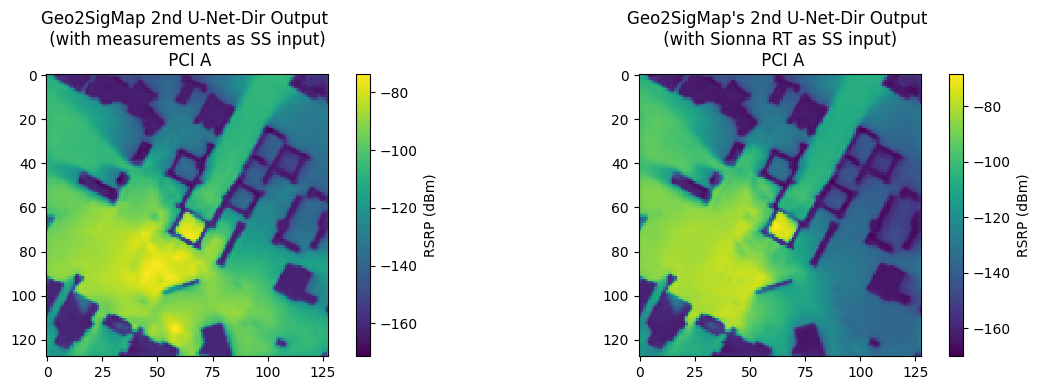

In [19]:
# Evaluation
images = torch.as_tensor(combined_input.copy()).float().contiguous()
rt_images = torch.as_tensor(rt_combined_input.copy()).float().contiguous()

# Since we directly load the data manually, add batch dimension to the front of data
images = images[None,:, :, :]
rt_images = rt_images[None,:, :, :]

net.eval()

images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
rt_images = rt_images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

with torch.no_grad():
    output = net(images).cpu()
    rt_output = net(rt_images).cpu()
output = output.squeeze().cpu().numpy()
rt_output = rt_output.squeeze().cpu().numpy()

# Create side-by-side plots for the ML model output using real-world measurement and Sionna RT as SS channel input
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

im_2nd_unet_output = axes[0].imshow(output, interpolation='none')
axes[0].set_title("Geo2SigMap 2nd U-Net-Dir Output \n (with measurements as SS input) \n PCI {}".format(which_PCI))
cbar_raw = plt.colorbar(im_2nd_unet_output, ax=axes[0])
cbar_raw.set_label('RSRP (dBm)')

im_ori_mea = axes[1].imshow(rt_output, interpolation='none')
axes[1].set_title("Geo2SigMap's 2nd U-Net-Dir Output \n (with Sionna RT as SS input) \n PCI {}".format(which_PCI))
cbar_db = plt.colorbar(im_ori_mea, ax=axes[1])
cbar_db.set_label('RSRP (dBm)')

plt.tight_layout()
plt.show()

## 4. **Performance Evaluation**: Quantitative Comparison with Field Measurements

We evaluate each model variant against the ground-truth RSRP measurements
at valid outdoor pixels (pixels with at least one field measurement, excluding
locations masked by building footprints).

Reported metrics:

| Metric | Description |
|--------|-------------|
| **RMSE (dB)** | Root Mean Square Error — penalises large individual errors |
| **MAE (dB)** | Mean Absolute Error — average per-pixel deviation |

In [20]:
def evaluate_predictions(y_true, y_pred, model_name):
    """Calculate comprehensive evaluation metrics"""
    mask = y_true != -160  # Ignore invalid pixels
    
    metrics = {
        'RMSE (dB)': root_mean_squared_error(y_true[mask], y_pred[mask]),
        'MAE (dB)': mean_absolute_error(y_true[mask], y_pred[mask]),
    }
    
    print(f"\n{model_name} Performance:")
    for k, v in metrics.items():
        print(f"- {k}: {v:.2f}")
    
    return metrics

# Compare all predictions
metrics_iso = evaluate_predictions(ground_truth_arr_valid, output_iso_UNet, "1st U-Net (Isotropic)")
metrics_adaptive = evaluate_predictions(ground_truth_arr_valid, output, "2nd U-Net (Directional)")

rt_metrics_adaptive = evaluate_predictions(ground_truth_arr_valid, rt_output, "2nd U-Net (Directional, with sparse measurements from Sionna RT)")


1st U-Net (Isotropic) Performance:
- RMSE (dB): 15.05
- MAE (dB): 12.24

2nd U-Net (Directional) Performance:
- RMSE (dB): 5.47
- MAE (dB): 4.10

2nd U-Net (Directional, with sparse measurements from Sionna RT) Performance:
- RMSE (dB): 16.40
- MAE (dB): 13.38
